# Portfolio Risk Analysis

A quantitative analysis of a multi-asset portfolio (equities + fixed income) 
using Python, covering return correlations, volatility, Value at Risk, 
factor exposure, and risk-adjusted performance.

## What this project covers

| Analysis | Method |
|---|---|
| Return correlations | Pearson correlation matrix across 6 assets |
| Volatility | 21-day rolling annualised volatility |
| Cumulative returns | Equity vs fixed income (2020–2024) |
| Value at Risk | Historical simulation at 95% and 99% confidence |
| Factor exposure | CAPM Beta relative to S&P 500 |
| Risk-adjusted return | Sharpe ratio with 5% risk-free rate |

## Assets
- **Equities:** AAPL, MSFT, JPM, GOOGL
- **Market benchmark:** SPY (S&P 500 ETF)
- **Fixed income:** TLT (20+ Year US Treasury Bond ETF)

## Key findings
- TLT demonstrates negative beta to SPY (-0.3 to -0.5 range), 
  confirming its role as an equity hedge
- Equity volatility spiked 3-4x during the COVID crash (Feb–May 2020) 
  and remained elevated through the 2022 rate hike cycle
- MSFT and AAPL delivered the highest Sharpe ratios among the equity universe

## Setup

```bash
pip install -r requirements.txt
jupyter notebook portfolio_risk_analysis.ipynb
```

## Tech stack
Python · pandas · NumPy · yfinance · matplotlib · seaborn · scipy

In [1]:
import os
import matplotlib.pyplot as plt

# Force save to your exact project folder
SAVE_PATH = r"C:\Users\Jashwanth\OneDrive\Desktop\Jashwanth_Documents\Projects\Portfolio-risk-analysis"

for i, name in enumerate(['correlation_matrix', 'rolling_volatility', 
                           'cumulative_returns', 'value_at_risk', 
                           'factor_exposure', 'sharpe_ratios']):
    try:
        plt.figure(i + 1)
        full_path = os.path.join(SAVE_PATH, f'{name}.png')
        plt.savefig(full_path, dpi=150, bbox_inches='tight')
        print(f"✓ Saved: {full_path}")
    except Exception as e:
        print(f"✗ Failed {name}: {e}")

✓ Saved: C:\Users\Jashwanth\OneDrive\Desktop\Jashwanth_Documents\Projects\Portfolio-risk-analysis\correlation_matrix.png
✓ Saved: C:\Users\Jashwanth\OneDrive\Desktop\Jashwanth_Documents\Projects\Portfolio-risk-analysis\rolling_volatility.png
✓ Saved: C:\Users\Jashwanth\OneDrive\Desktop\Jashwanth_Documents\Projects\Portfolio-risk-analysis\cumulative_returns.png
✓ Saved: C:\Users\Jashwanth\OneDrive\Desktop\Jashwanth_Documents\Projects\Portfolio-risk-analysis\value_at_risk.png
✓ Saved: C:\Users\Jashwanth\OneDrive\Desktop\Jashwanth_Documents\Projects\Portfolio-risk-analysis\factor_exposure.png
✓ Saved: C:\Users\Jashwanth\OneDrive\Desktop\Jashwanth_Documents\Projects\Portfolio-risk-analysis\sharpe_ratios.png


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [2]:
import sys
!{sys.executable} -m pip install yfinance pandas numpy matplotlib seaborn scipy

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("husl")

print("Libraries loaded successfully")

Libraries loaded successfully


In [4]:
# Define assets: equities + fixed income proxy
TICKERS = ['AAPL', 'MSFT', 'JPM', 'GOOGL', 'SPY', 'TLT']
START = '2020-01-01'
END   = '2024-12-31'

print(f"Downloading data for: {TICKERS}")
raw = yf.download(TICKERS, start=START, end=END, auto_adjust=True)['Close']
prices = raw.dropna()

print(f"\nData shape: {prices.shape}")
print(f"Date range: {prices.index[0].date()} to {prices.index[-1].date()}")
prices.tail(3)

[*********************100%***********************]  6 of 6 completed


Data shape: (1257, 6)
Date range: 2020-01-02 to 2024-12-30


Ticker,AAPL,GOOGL,JPM,MSFT,SPY,TLT
Date,,,,,,
2024-12-26,257.375549,194.69989,235.823624,433.911407,592.741577,82.841988
2024-12-27,253.967361,191.87294,233.912888,426.404083,586.502014,82.162788
2024-12-30,250.598877,190.35994,232.118576,420.758667,579.809143,82.823120


In [5]:
# Daily log returns (more statistically sound than simple returns)
returns = np.log(prices / prices.shift(1)).dropna()

# Summary statistics
summary = returns.describe().T
summary['annualised_vol'] = returns.std() * np.sqrt(252)
summary['annualised_return'] = returns.mean() * 252

print("=== Return Summary ===")
print(summary[['mean', 'std', 'annualised_return', 'annualised_vol']].round(4))

=== Return Summary ===
          mean     std  annualised_return  annualised_vol
Ticker                                                   
AAPL    0.0010  0.0199             0.2493          0.3166
GOOGL   0.0008  0.0205             0.2069          0.3253
JPM     0.0005  0.0204             0.1350          0.3246
MSFT    0.0008  0.0192             0.2041          0.3053
SPY     0.0005  0.0133             0.1343          0.2109
TLT    -0.0003  0.0113            -0.0637          0.1796


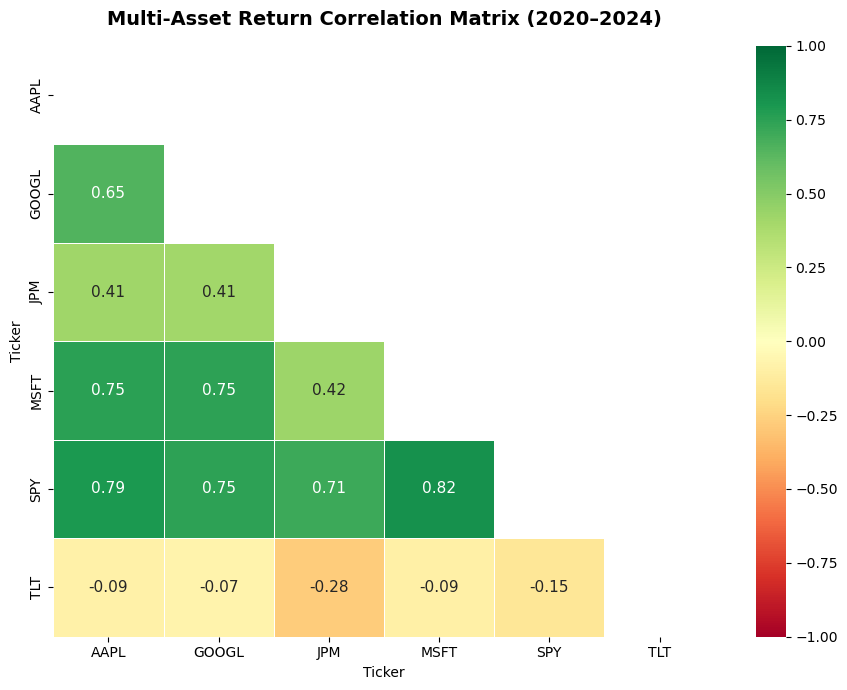

Key insight: TLT (bonds) shows negative/low correlation with equities — diversification benefit


In [6]:
fig, ax = plt.subplots(figsize=(9, 7))

corr = returns.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    vmin=-1, vmax=1,
    mask=mask,
    ax=ax,
    linewidths=0.5,
    annot_kws={'size': 11}
)

ax.set_title('Multi-Asset Return Correlation Matrix (2020–2024)',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Key insight: TLT (bonds) shows negative/low correlation with equities — diversification benefit")

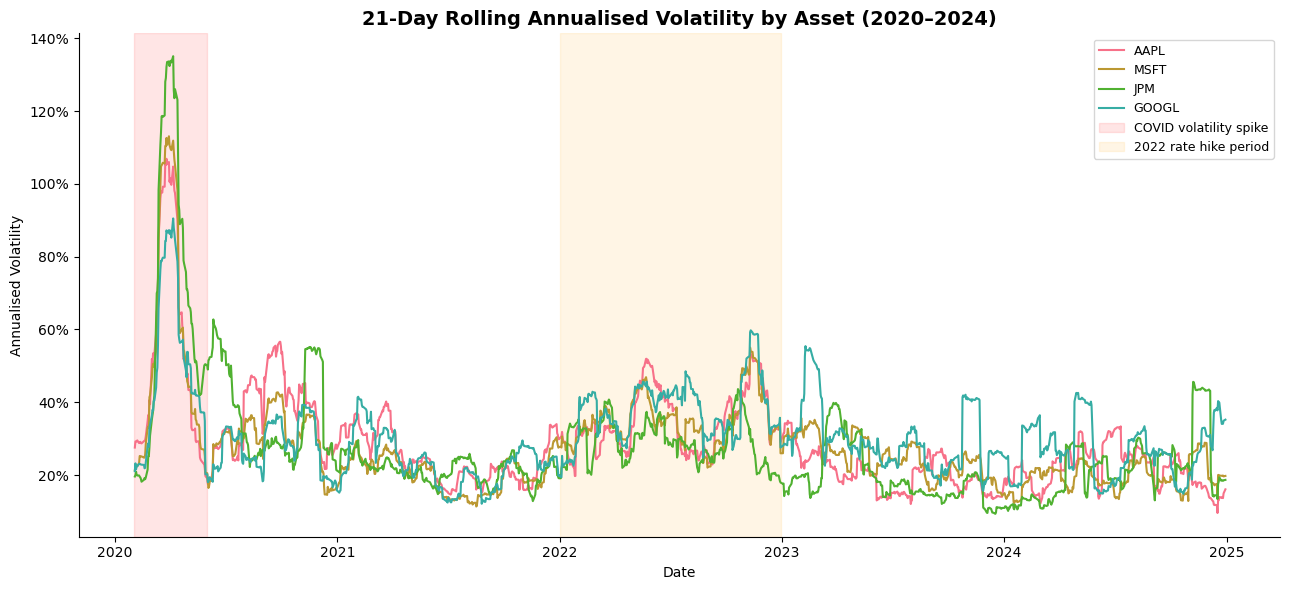

In [7]:
# 21-trading-day rolling volatility, annualised
WINDOW = 21
equity_tickers = ['AAPL', 'MSFT', 'JPM', 'GOOGL']

rolling_vol = returns[equity_tickers].rolling(WINDOW).std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(13, 6))

for ticker in equity_tickers:
    ax.plot(rolling_vol.index, rolling_vol[ticker], label=ticker, linewidth=1.5)

# Shade COVID crash period
ax.axvspan('2020-02-01', '2020-06-01', alpha=0.1, color='red', label='COVID volatility spike')
ax.axvspan('2022-01-01', '2022-12-31', alpha=0.1, color='orange', label='2022 rate hike period')

ax.set_title('21-Day Rolling Annualised Volatility by Asset (2020–2024)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Annualised Volatility')
ax.set_xlabel('Date')
ax.legend(loc='upper right', fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout()
plt.savefig('rolling_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

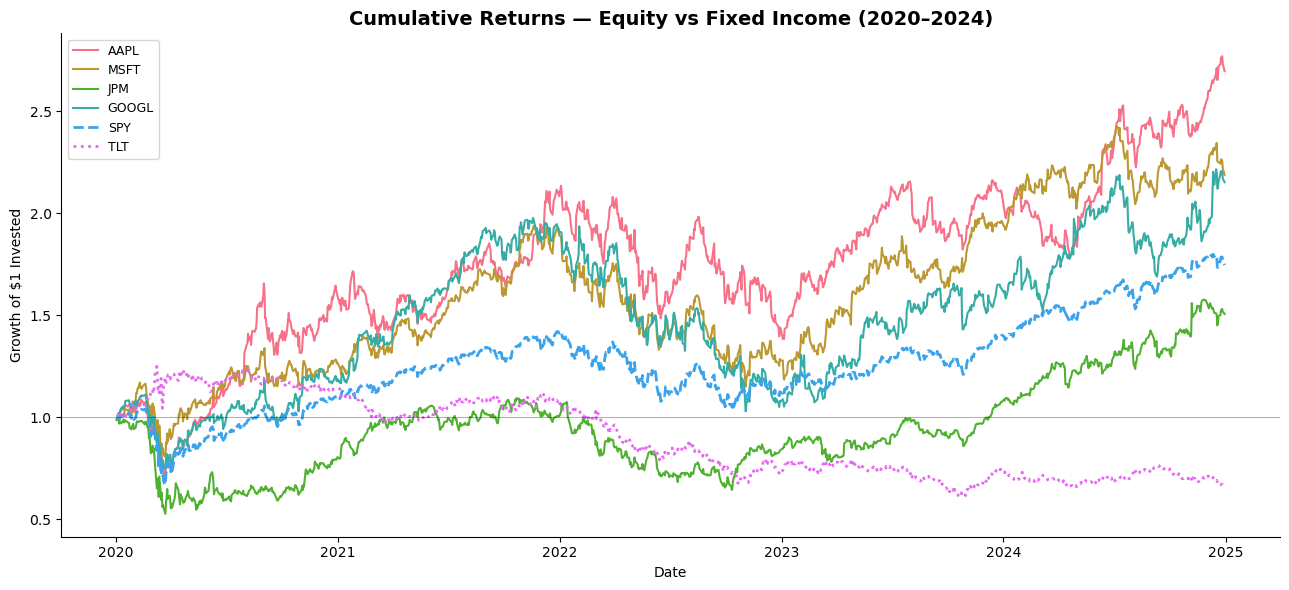

In [8]:
cum_returns = (1 + returns[TICKERS]).cumprod()

fig, ax = plt.subplots(figsize=(13, 6))

styles = {
    'AAPL': '-', 'MSFT': '-', 'JPM': '-', 'GOOGL': '-',
    'SPY': '--', 'TLT': ':'
}

for ticker in TICKERS:
    ax.plot(
        cum_returns.index,
        cum_returns[ticker],
        linestyle=styles[ticker],
        label=ticker,
        linewidth=2 if ticker in ['SPY', 'TLT'] else 1.5
    )

ax.axhline(y=1, color='black', linewidth=0.8, linestyle='-', alpha=0.3)
ax.set_title('Cumulative Returns — Equity vs Fixed Income (2020–2024)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Growth of $1 Invested')
ax.set_xlabel('Date')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()

=== Portfolio Value at Risk (Historical Simulation) ===
Portfolio value: $100,000
Period: 2020-01-01 to 2024-12-31

  95% VaR: -0.0239 daily return = $2,393 potential 1-day loss
  99% VaR: -0.0456 daily return = $4,561 potential 1-day loss


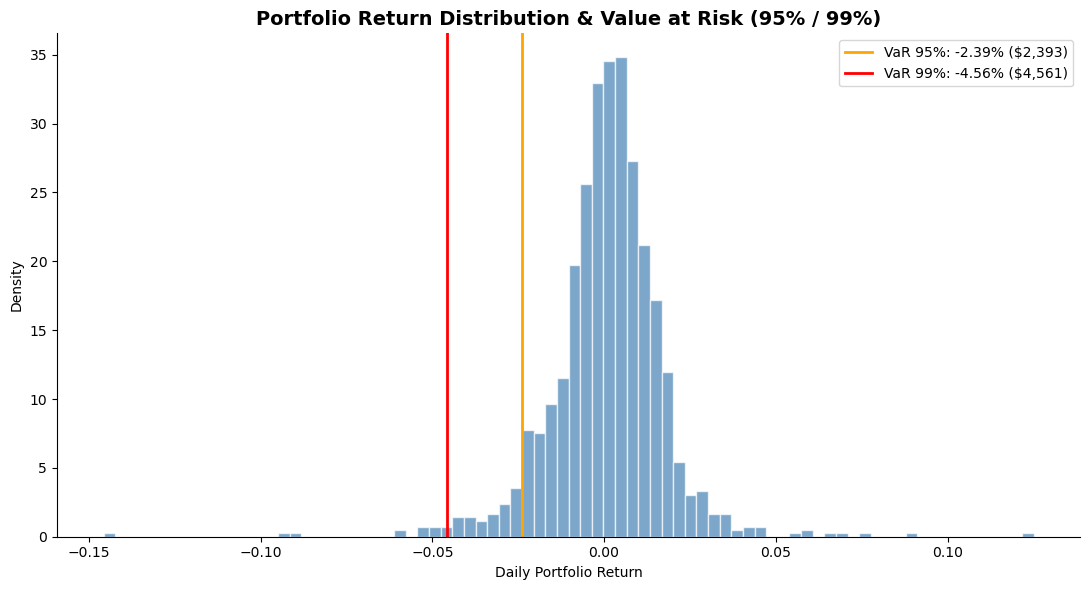

In [9]:
# Equal-weight portfolio
equity_returns = returns[['AAPL', 'MSFT', 'JPM', 'GOOGL']]
weights = np.array([0.25, 0.25, 0.25, 0.25])
portfolio_returns = equity_returns.dot(weights)

# Historical simulation VaR
confidence_levels = [0.95, 0.99]
portfolio_value = 100_000  # $100,000 hypothetical portfolio

print("=== Portfolio Value at Risk (Historical Simulation) ===")
print(f"Portfolio value: ${portfolio_value:,}")
print(f"Period: {START} to {END}\n")

fig, ax = plt.subplots(figsize=(11, 6))

ax.hist(portfolio_returns, bins=80, color='steelblue',
        edgecolor='white', alpha=0.7, density=True)

colors = ['orange', 'red']
for cl, color in zip(confidence_levels, colors):
    var = np.percentile(portfolio_returns, (1 - cl) * 100)
    dollar_var = abs(var) * portfolio_value
    ax.axvline(var, color=color, linewidth=2,
               label=f'VaR {cl:.0%}: {var:.2%} (${dollar_var:,.0f})')
    print(f"  {cl:.0%} VaR: {var:.4f} daily return = ${dollar_var:,.0f} potential 1-day loss")

ax.set_title('Portfolio Return Distribution & Value at Risk (95% / 99%)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Daily Portfolio Return')
ax.set_ylabel('Density')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('value_at_risk.png', dpi=150, bbox_inches='tight')
plt.show()

=== Factor Exposure: CAPM Beta to S&P 500 (SPY) ===

  AAPL   Beta: 1.190  |  Alpha (annualised): 0.0895  |  R²: 0.628
  MSFT   Beta: 1.188  |  Alpha (annualised): 0.0446  |  R²: 0.673
  JPM    Beta: 1.093  |  Alpha (annualised): -0.0117  |  R²: 0.504
  GOOGL  Beta: 1.151  |  Alpha (annualised): 0.0523  |  R²: 0.557
  TLT    Beta: -0.127  |  Alpha (annualised): -0.0466  |  R²: 0.022


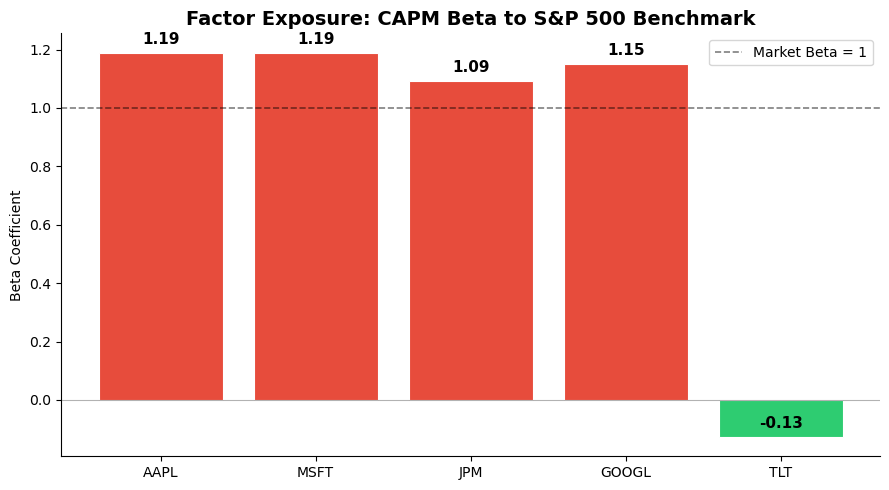


Interpretation: Beta > 1 = more volatile than market | Beta < 0 = negatively correlated (TLT hedges equity risk)


In [10]:
# CAPM Beta: measures sensitivity of each asset to market movements
market_returns = returns['SPY']

print("=== Factor Exposure: CAPM Beta to S&P 500 (SPY) ===\n")

betas = {}
alphas = {}

for ticker in ['AAPL', 'MSFT', 'JPM', 'GOOGL', 'TLT']:
    asset_ret = returns[ticker]
    slope, intercept, r_value, p_value, _ = stats.linregress(
        market_returns, asset_ret
    )
    betas[ticker]  = slope
    alphas[ticker] = intercept * 252  # Annualised alpha
    print(f"  {ticker:5s}  Beta: {slope:.3f}  |  Alpha (annualised): {intercept*252:.4f}  |  R²: {r_value**2:.3f}")

# Bar chart
fig, ax = plt.subplots(figsize=(9, 5))
tickers_plot = list(betas.keys())
beta_vals    = list(betas.values())
colors = ['#e74c3c' if b > 1 else '#2ecc71' if b < 0.5 else '#3498db' for b in beta_vals]

bars = ax.bar(tickers_plot, beta_vals, color=colors, edgecolor='white', linewidth=0.8)
ax.axhline(y=1, color='black', linewidth=1.2, linestyle='--', alpha=0.5, label='Market Beta = 1')
ax.axhline(y=0, color='black', linewidth=0.8, alpha=0.3)

for bar, val in zip(bars, beta_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_title('Factor Exposure: CAPM Beta to S&P 500 Benchmark',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Beta Coefficient')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('factor_exposure.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInterpretation: Beta > 1 = more volatile than market | Beta < 0 = negatively correlated (TLT hedges equity risk)")

=== Risk-Adjusted Performance: Sharpe Ratios ===

  AAPL   Return: 24.93%  |  Vol: 31.66%  |  Sharpe: 0.629
  MSFT   Return: 20.41%  |  Vol: 30.53%  |  Sharpe: 0.505
  JPM    Return: 13.50%  |  Vol: 32.46%  |  Sharpe: 0.262
  GOOGL  Return: 20.69%  |  Vol: 32.53%  |  Sharpe: 0.482
  SPY    Return: 13.43%  |  Vol: 21.09%  |  Sharpe: 0.400
  TLT    Return: -6.37%  |  Vol: 17.96%  |  Sharpe: -0.633


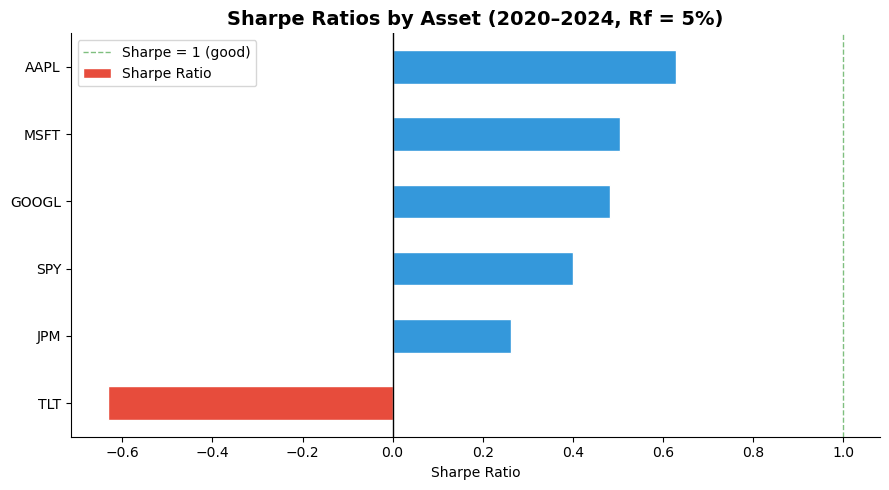

In [11]:
RISK_FREE = 0.05  # Approximate US risk-free rate 2020-2024 average

print("=== Risk-Adjusted Performance: Sharpe Ratios ===\n")

sharpe_data = {}
for ticker in TICKERS:
    ann_return = returns[ticker].mean() * 252
    ann_vol    = returns[ticker].std()  * np.sqrt(252)
    sharpe     = (ann_return - RISK_FREE) / ann_vol
    sharpe_data[ticker] = {
        'Annualised Return': ann_return,
        'Annualised Vol':    ann_vol,
        'Sharpe Ratio':      sharpe
    }
    print(f"  {ticker:5s}  Return: {ann_return:.2%}  |  Vol: {ann_vol:.2%}  |  Sharpe: {sharpe:.3f}")

sharpe_df = pd.DataFrame(sharpe_data).T.sort_values('Sharpe Ratio', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e74c3c' if s < 0 else '#3498db' if s < 1 else '#2ecc71'
          for s in sharpe_df['Sharpe Ratio']]
sharpe_df['Sharpe Ratio'].plot(kind='barh', ax=ax, color=colors, edgecolor='white')

ax.axvline(x=0, color='black', linewidth=1)
ax.axvline(x=1, color='green', linewidth=1, linestyle='--', alpha=0.5, label='Sharpe = 1 (good)')
ax.set_title('Sharpe Ratios by Asset (2020–2024, Rf = 5%)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Sharpe Ratio')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('sharpe_ratios.png', dpi=150, bbox_inches='tight')
plt.show()